# Pneumonia Risk Prediction with TabPNF

## Objective

I previously worked on a problem to develop a pneumonia risk prediction model capable of identifying patients at elevated risk for postoperative pneumonia. Because pneumonia cases were relatively uncommon in the dataset, the task represented a class-imbalanced binary classification problem.

Two modeling approaches were evaluated:

1. A hybrid kNN + Random Forest (RF) pipeline
2. A TabPFN (Tabular Prior-data Fitted Network) classifier

---

# kNN + Random Forest Model

## Methodology

In the kNN/RF approach, a k-Nearest Neighbors (kNN) model was first trained on the training dataset and used to predict probabilities for samples within the same training set. A probability threshold was then applied to identify observations likely belonging to the positive class (pneumonia cases). These filtered observations were subsequently used to train a Random Forest classifier, which generated the final predictions.

This approach was designed to improve sensitivity for the minority class by enriching the training data with observations more likely to represent positive pneumonia cases.

---

## Performance

### Metrics

| Metric | Value |
|---|---|
| Accuracy | 0.62 |
| Precision | 0.11 |
| Recall | 0.64 |
| F1-score | 0.19 |
| ROC-AUC | 0.68 |

### Interpretation

The kNN/RF model demonstrated relatively high recall (64%), meaning the model successfully identified a majority of pneumonia cases. This indicates strong sensitivity and suggests the model may be useful as a screening or triage tool.

However, precision was very low (11%), indicating that many patients predicted to develop pneumonia were actually false positives. The confusion matrix demonstrated this imbalance clearly:

- True positives: 84
- False negatives: 48
- False positives: 667
- True negatives: 1066

The model therefore prioritized sensitivity at the expense of specificity. While this may be acceptable in some clinical screening applications where missing pneumonia cases is undesirable, the large number of false positives would likely limit clinical practicality.

The ROC-AUC of 0.68 indicated only moderate discriminatory performance overall.

---

# TabPFN Model

## Methodology

In the AMIDD module I tried applying TabPFN "out-of-the-box" to the prbolem but it did not offer any significant improvement. In this trial I the TabPFN classifier was trained using stratified cross-validation in hopes of better estimate generalization performance across multiple train-validation splits. Because the dataset was highly imbalanced, performance evaluation focused not only on accuracy, but also on:

- ROC-AUC
- Precision-Recall AUC (PR-AUC)
- Recall
- F1-score
- Threshold optimization

The default classification threshold of 0.5 resulted in poor sensitivity for pneumonia detection. Therefore, probability threshold tuning was performed to identify a threshold that maximized F1-score and improved minority-class detection.

The optimal threshold identified was approximately:

```text
0.117
```

This means that patients with a predicted pneumonia probability greater than or equal to 11.7% were classified as positive cases.

---

## Cross-Validated Performance

### Mean Cross-Validation Metrics

| Metric | Value |
|---|---|
| ROC-AUC | 0.778 |
| PR-AUC | 0.253 |

The TabPFN model demonstrated stronger discriminatory ability than the kNN/RF model, as reflected by the higher ROC-AUC.

---

## Threshold Optimization Results

### Default Threshold (0.5)

| Metric | Value |
|---|---|
| Accuracy | 0.93 |
| Precision | 0.71 |
| Recall | 0.04 |
| F1-score | 0.08 |

At the default threshold, the model rarely predicted pneumonia, resulting in very high accuracy but extremely poor recall. This occurred because the model strongly favored the majority negative class.

---

### Optimized Threshold (0.117)

| Metric | Value |
|---|---|
| Accuracy | 0.85 |
| Precision | 0.22 |
| Recall | 0.44 |
| F1-score | 0.29 |

Lowering the threshold substantially improved recall and F1-score while maintaining acceptable overall discrimination.

---

# Comparison of Models

## Sensitivity vs Specificity Tradeoff

The two models demonstrated different tradeoffs:

### kNN/RF Model
- Higher recall (0.64)
- Lower precision (0.11)
- More false positives
- Lower ROC-AUC (0.68)

### TabPFN Model
- Better overall discrimination (ROC-AUC ≈ 0.78)
- Improved precision (0.22)
- Lower recall than kNN/RF
- Better balanced performance overall

The kNN/RF approach aggressively identified positive cases, making it more sensitive but substantially less specific. In contrast, the TabPFN model produced a more balanced classifier with stronger global predictive performance.

---

# Final Interpretation and Limitations

Overall, the TabPFN model demonstrated improved balance between sensitivity and precision compared to the kNN/RF pipeline and achieved stronger overall discriminatory performance based on ROC-AUC. Cross-validation also suggested that the model generalized more consistently across different train-validation splits. However, despite these improvements, the model performance still falls short of what would likely be considered clinically actionable in a real-world healthcare setting.

Several important limitations likely contributed to this outcome.

First, the dataset was highly imbalanced, with pneumonia cases representing only a small proportion of the total observations. This created substantial difficulty for the model, as standard classification algorithms naturally favored the majority negative class. Although threshold optimization improved recall considerably, this improvement came at the expense of many false positives and relatively low precision. In practice, this means the model would incorrectly flag a large number of patients as high risk for pneumonia.

Second, the dataset contained missing values and incomplete clinical information. While TabPFN can internally handle missing values, missingness itself may still reduce predictive quality because clinically important variables may not have been consistently available across patients. Additionally, missing values in healthcare data are often not random and may reflect underlying clinical or documentation processes that are difficult for machine learning models to fully capture.

Another limitation is that the available features may not adequately represent the true drivers of postoperative pneumonia risk so the model may only capture a portion of the underlying clinical complexity associated with pneumonia development.

The results also highlight the broader challenge of applying machine learning to relatively rare clinical outcomes as we learned earlier this semester with the example of precision and recall of 90%.

In [ ]:
from collections import Counter

import numpy as np
import pandas as pd

from sklearn.model_selection import StratifiedKFold
from imblearn.over_sampling import SMOTE
from sklearn.impute import KNNImputer
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    average_precision_score,
    precision_recall_curve,
    f1_score,
    recall_score,
    precision_score
)

from tabpfn import TabPFNClassifier
df = pd.read_csv("finalized_data_set")

# -----------------------------
# 1. Define X and y
# -----------------------------

drop_cols = [
    'record_id','mortal_yn', 'pe_yn', 'respul_fail_yn', 'pneumonia_yn',
    'eligibility_complete'
    
]

X = df.drop(drop_cols, axis=1)
y = df['pneumonia_yn'].astype(int)

# Important: use np.nan, not pd.NA
X = X.replace({pd.NA: np.nan})


# -----------------------------
# Cross-validation setup
# -----------------------------

cv = StratifiedKFold(
    n_splits=3,
    shuffle=True,
    random_state=42
)

use_smote = False
thresholds_to_report = [0.50, 0.30, 0.20, 0.10]

fold_results = []
all_y_true = []
all_y_prob = []


# -----------------------------
# Cross-validation loop
# -----------------------------

for fold, (train_idx, test_idx) in enumerate(cv.split(X, y), start=1):

    X_train = X.iloc[train_idx].copy()
    X_test = X.iloc[test_idx].copy()
    y_train = y.iloc[train_idx].copy()
    y_test = y.iloc[test_idx].copy()

    print(f"\n===== Fold {fold} =====")
    print("Training distribution:", Counter(y_train))
    print("Validation distribution:", Counter(y_test))

    # SMOTE does NOT handle missing values well.
    # So only use SMOTE if you also impute first.
    if use_smote:
        from sklearn.impute import SimpleImputer

        imputer = SimpleImputer(strategy="median")

        X_train_for_smote = pd.DataFrame(
            imputer.fit_transform(X_train),
            columns=X_train.columns,
            index=X_train.index
        )

        X_test_model = pd.DataFrame(
            imputer.transform(X_test),
            columns=X_test.columns,
            index=X_test.index
        )

        smote = SMOTE(
            sampling_strategy=0.30,
            random_state=42,
            k_neighbors=5
        )

        X_train_model, y_train_model = smote.fit_resample(
            X_train_for_smote,
            y_train
        )

    else:
        # Native TabPFN missing-value handling
        X_train_model = X_train
        y_train_model = y_train
        X_test_model = X_test

    print("Training distribution after resampling:", Counter(y_train_model))

    clf = TabPFNClassifier(
        ignore_pretraining_limits=True
    )

    clf.fit(X_train_model, y_train_model)

    y_prob = clf.predict_proba(X_test_model)[:, 1]

    fold_roc_auc = roc_auc_score(y_test, y_prob)
    fold_pr_auc = average_precision_score(y_test, y_prob)

    print("ROC AUC:", round(fold_roc_auc, 4))
    print("PR AUC:", round(fold_pr_auc, 4))

    fold_results.append({
        "fold": fold,
        "roc_auc": fold_roc_auc,
        "pr_auc": fold_pr_auc
    })

    all_y_true.extend(y_test)
    all_y_prob.extend(y_prob)


# -----------------------------
# Aggregate CV performance
# -----------------------------

results_df = pd.DataFrame(fold_results)

print("\n==============================")
print("Cross-validated performance")
print("==============================")
print(results_df)
print("\nMean ROC AUC:", round(results_df["roc_auc"].mean(), 4))
print("SD ROC AUC:", round(results_df["roc_auc"].std(), 4))
print("Mean PR AUC:", round(results_df["pr_auc"].mean(), 4))
print("SD PR AUC:", round(results_df["pr_auc"].std(), 4))


# -----------------------------
# Threshold tuning on pooled CV predictions
# -----------------------------

all_y_true = np.array(all_y_true)
all_y_prob = np.array(all_y_prob)

precision, recall, thresholds = precision_recall_curve(all_y_true, all_y_prob)
f1_scores = 2 * precision * recall / (precision + recall + 1e-9)

best_idx = np.argmax(f1_scores[:-1])
best_threshold = thresholds[best_idx]

print("\nBest pooled CV threshold by F1:", round(best_threshold, 4))
print("Best pooled CV F1:", round(f1_scores[best_idx], 4))
print("Precision at best threshold:", round(precision[best_idx], 4))
print("Recall at best threshold:", round(recall[best_idx], 4))


# -----------------------------
# Evaluate selected thresholds
# -----------------------------

def evaluate_threshold(y_true, y_prob, threshold):
    y_pred = (y_prob >= threshold).astype(int)

    print("\n==============================")
    print(f"Threshold: {threshold}")
    print("==============================")
    print("Accuracy:", round(accuracy_score(y_true, y_pred), 4))
    print("Precision:", round(precision_score(y_true, y_pred, zero_division=0), 4))
    print("Recall:", round(recall_score(y_true, y_pred, zero_division=0), 4))
    print("F1:", round(f1_score(y_true, y_pred, zero_division=0), 4))
    print("Confusion matrix:")
    print(confusion_matrix(y_true, y_pred))
    print(classification_report(y_true, y_pred, zero_division=0))


evaluate_threshold(all_y_true, all_y_prob, 0.50)
evaluate_threshold(all_y_true, all_y_prob, best_threshold)

for t in thresholds_to_report:
    evaluate_threshold(all_y_true, all_y_prob, t)


===== Fold 1 =====
Training distribution: Counter({0: 3842, 1: 300})
Validation distribution: Counter({0: 1922, 1: 150})
Training distribution after resampling: Counter({0: 3842, 1: 300})
ROC AUC: 0.7869
PR AUC: 0.2696

===== Fold 2 =====
Training distribution: Counter({0: 3843, 1: 300})
Validation distribution: Counter({0: 1921, 1: 150})
Training distribution after resampling: Counter({0: 3843, 1: 300})
ROC AUC: 0.7867
PR AUC: 0.2616

===== Fold 3 =====
Training distribution: Counter({0: 3843, 1: 300})
Validation distribution: Counter({0: 1921, 1: 150})
Training distribution after resampling: Counter({0: 3843, 1: 300})
ROC AUC: 0.7593
PR AUC: 0.2278

Cross-validated performance
   fold   roc_auc    pr_auc
0     1  0.786885  0.269612
1     2  0.786681  0.261594
2     3  0.759337  0.227758

Mean ROC AUC: 0.7776
SD ROC AUC: 0.0158
Mean PR AUC: 0.253
SD PR AUC: 0.0222

Best pooled CV threshold by F1: 0.117
Best pooled CV F1: 0.2919
Precision at best threshold: 0.2189
Recall at best thres

### Benchmark results
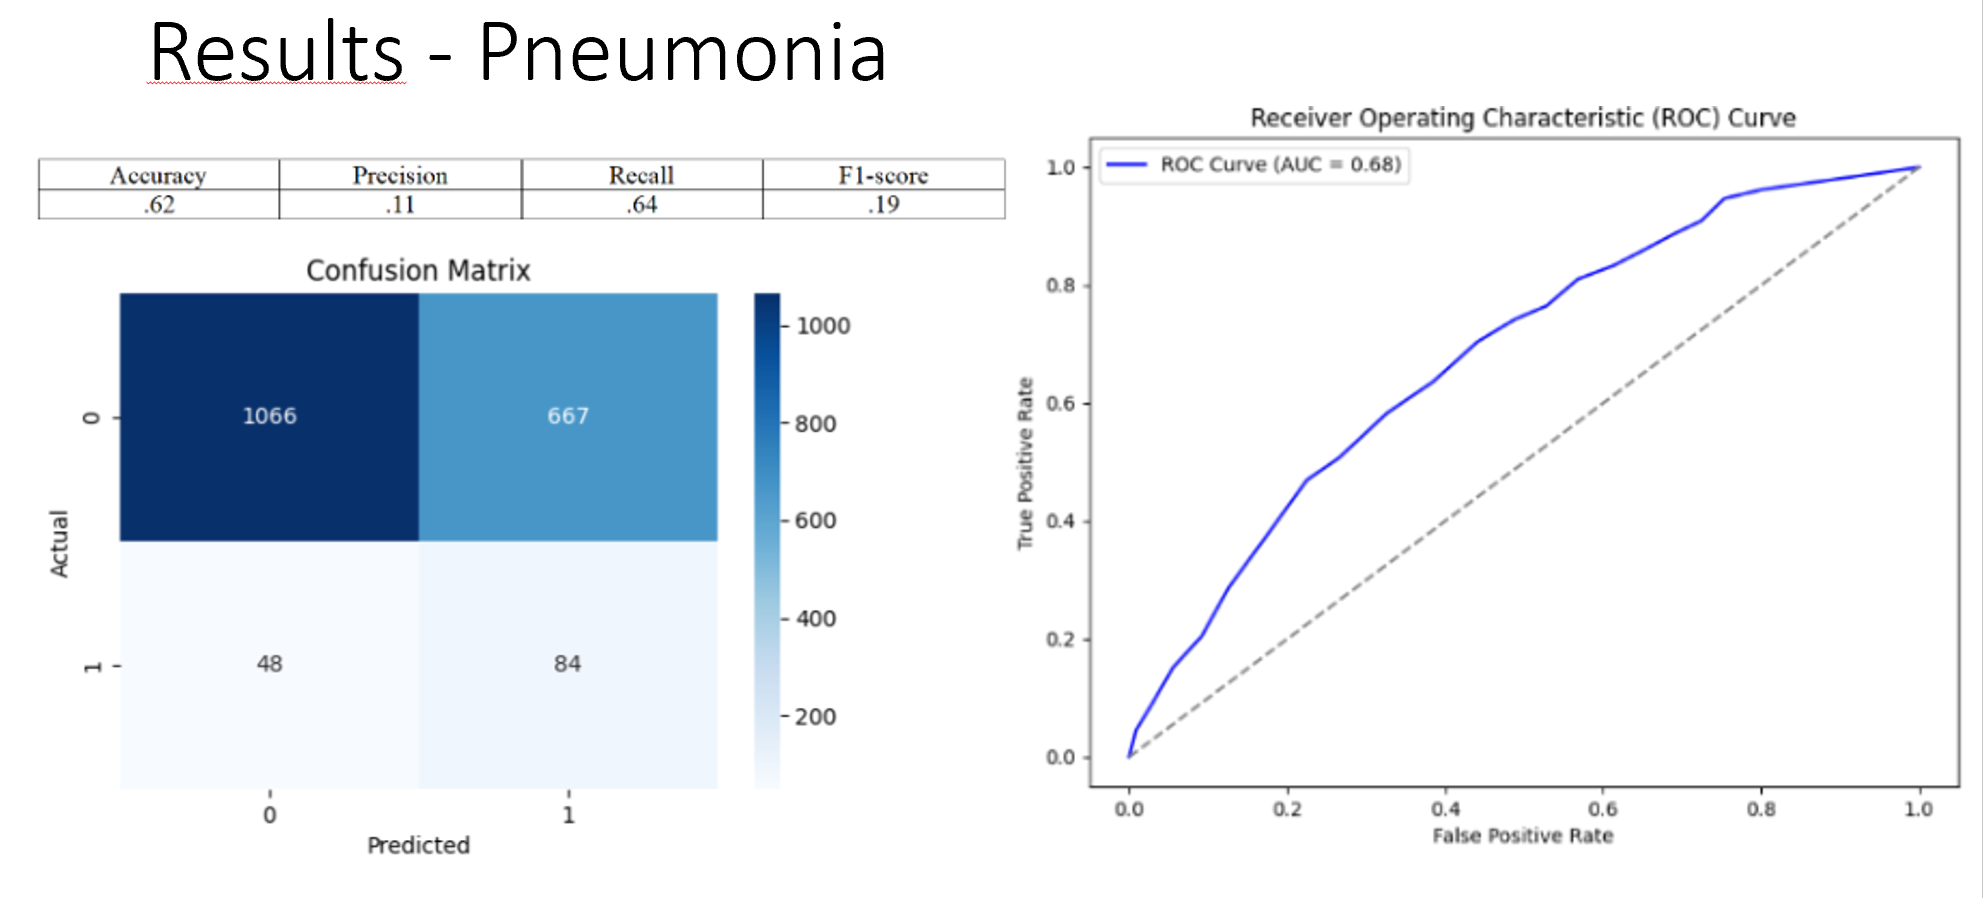